# Linear Mixed-Effects Model — Response Time

**Revision additions (Reviewer 3, Comment 7):**
1. **Phonological similarity of the string** (`phon_sim_c`) — mean pairwise cosine similarity among German letter names in the encoding string.
2. **Probe–string phonological similarity** (`probe_phon_sim_c`) — mean cosine similarity between the probe letter and the letters in the encoding string (excluding the probe itself on IN trials). Low values = phonologically distinct probe = expected faster RT.
3. **Normalised serial position** (`serial_pos_norm_IN_c`) — position of the probe within the string scaled to [0, 1] by set size: `(pos − 1) / (set_size − 1)`. This removes the confound between raw position and string length. Enters the model only for IN trials (0 for OUT), mean-centred within IN trials to avoid collinearity with the trial-type dummy.

Full model:
```
RT ~ DecodingAccuracy              (mean-centred over all trials)
   + PhonStringSimilarity           (mean-centred over all trials)
   + ProbeStringSimilarity          (mean-centred over all trials)
   + C(trial_type)                  (IN vs OUT; OUT = reference)
   + C(size)                        (set size 4/6/8; 4 = reference)
   + C(probe)                       (probe letter; G = reference)
   + serial_pos_norm_IN_c           (normalised position ∈ [0,1], centred within IN; 0 for OUT)
   + (1 | subject)
```

**Why `serial_pos_norm_IN_c` is not an interaction term:**  
Using `C(trial_type)[T.IN]:serial_pos_norm_IN` causes `LinAlgError: Singular matrix`
because the interaction is perfectly collinear with `C(trial_type)[T.IN]`
(the term is always > 0 on IN trials, never 0).  
The fix is to **mean-centre within IN trials** and enter as a plain term.
After centring, the term is 0 for OUT trials *and* 0 at the mean IN position,
eliminating collinearity while estimating the position slope from IN-trial variance only.


In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import re
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


## 1. Phonological Feature Matrix (German)

Each of the 15 consonant letters is described by 17 binary IPA features
based on its **German letter name** (Hochdeutsch standard).

| Letter | German name | IPA | Rhyme group |
|--------|------------|-----|-------------|
| B | be | /beː/ | /eː/ |
| C | ze | /tseː/ | /eː/ |
| D | de | /deː/ | /eː/ |
| F | ef | /ɛf/ | /ɛ_/ (vowel-initial) |
| G | ge | /ɡeː/ | /eː/ |
| H | ha | /haː/ | /aː/ |
| K | ka | /kaː/ | /aː/ |
| L | el | /ɛl/ | /ɛ_/ (vowel-initial) |
| N | en | /ɛn/ | /ɛ_/ (vowel-initial) |
| P | pe | /peː/ | /eː/ |
| R | er | /ɛr/ | /ɛ_/ (vowel-initial) |
| S | es | /ɛs/ | /ɛ_/ (vowel-initial) |
| T | te | /teː/ | /eː/ |
| V | fau | /faʊ/ | /aʊ/ (unique) |
| Z | zet | /tsɛt/ | /ɛ_/ |

**Rhyme groups:** /eː/ → B C D G P T · /aː/ → H K · /ɛ_/ → F L N R S Z · /aʊ/ → V

**Key differences from English** that change the similarity structure:
- C = /tseː/ and Z = /tsɛt/ share the same affricate onset /ts/
- H = /haː/ rhymes with K = /kaː/ (unlike English H = /eɪtʃ/)
- V = /faʊ/ has a unique rhyme — least confusable of all letters
- G = /ɡeː/ is a plain velar stop (not the affricate /dʒ/ of English)
- The critical /eː/ rhyme group is **B C D G P T** (6 letters, not 7 as in English /iː/)

Features: **Manner** (stop, fricative, affricate, nasal, lateral, trill) +
**Place** (bilabial, labiodental, alveolar, velar, glottal) +
**Voicing** + **vowel_onset** + **4 rhyme groups** = 17 features total.

Trial-level `phon_sim` = mean pairwise cosine similarity of the letters
in that trial's encoding string.


In [2]:
LETTERS = ['B','C','D','F','G','H','K','L','N','P','R','S','T','V','Z']

# German letter name IPA transcriptions:
# B=/beː/ C=/tseː/ D=/deː/ F=/ɛf/  G=/ɡeː/ H=/haː/ K=/kaː/
# L=/ɛl/  N=/ɛn/  P=/peː/ R=/ɛr/  S=/ɛs/  T=/teː/ V=/faʊ/ Z=/tsɛt/

FEAT_NAMES = [
    'voiced',         #  0
    'bilabial',       #  1
    'labiodental',    #  2
    'alveolar',       #  3
    'velar',          #  4
    'glottal',        #  5  ← H = /h/ in German
    'affricate',      #  6
    'fricative',      #  7
    'nasal',          #  8
    'stop',           #  9
    'lateral',        # 10  ← /l/
    'trill',          # 11  ← German /r/
    'vowel_onset',    # 12: name starts with /ɛ/ (F L N R S)
    'rhyme_ee',       # 13: /eː/ coda — B C D G P T
    'rhyme_aa',       # 14: /aː/ coda — H K
    'rhyme_eps',      # 15: /ɛ_/ coda — F L N R S Z
    'rhyme_au',       # 16: /aʊ/ coda — V (unique)
]

# Rows: B C D F G H K L N P R S T V Z
# Cols: [voiced, bilabial, labiodental, alveolar, velar, glottal,
#        affricate, fricative, nasal, stop, lateral, trill,
#        vowel_onset, rhyme_ee, rhyme_aa, rhyme_eps, rhyme_au]
FEAT_MATRIX = np.array([
 # B  /beː/ — voiced bilabial stop, rhyme /eː/
 [1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # C  /tseː/ — voiceless alveolar affricate /ts/, rhyme /eː/
 [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
 # D  /deː/ — voiced alveolar stop, rhyme /eː/
 [1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # F  /ɛf/ — vowel-initial; coda = voiceless labiodental fricative, rhyme /ɛ_/
 [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0],
 # G  /ɡeː/ — voiced velar stop, rhyme /eː/
 [1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # H  /haː/ — voiceless glottal fricative, rhyme /aː/
 [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
 # K  /kaː/ — voiceless velar stop, rhyme /aː/
 [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
 # L  /ɛl/ — vowel-initial; coda = voiced alveolar lateral, rhyme /ɛ_/
 [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0],
 # N  /ɛn/ — vowel-initial; coda = voiced alveolar nasal, rhyme /ɛ_/
 [1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0],
 # P  /peː/ — voiceless bilabial stop, rhyme /eː/
 [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # R  /ɛr/ — vowel-initial; coda = voiced alveolar/uvular trill, rhyme /ɛ_/
 [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0],
 # S  /ɛs/ — vowel-initial; coda = voiceless alveolar fricative, rhyme /ɛ_/
 [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0],
 # T  /teː/ — voiceless alveolar stop, rhyme /eː/
 [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # V  /faʊ/ — voiceless labiodental fricative, unique rhyme /aʊ/
 [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 # Z  /tsɛt/ — voiceless alveolar affricate /ts/, rhyme /ɛ_/
 [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
], dtype=float)

# ── Pairwise cosine similarity ──────────────────────────────────────────
norms     = np.linalg.norm(FEAT_MATRIX, axis=1, keepdims=True)
FEAT_NORM = FEAT_MATRIX / norms
COS_SIM   = FEAT_NORM @ FEAT_NORM.T

LETTER_IDX = {l: i for i, l in enumerate(LETTERS)}

sim_df = pd.DataFrame(np.round(COS_SIM, 3), index=LETTERS, columns=LETTERS)
print('German IPA pairwise cosine similarity:')
print(sim_df)

print('\nSanity checks:')
print(f'  C-Z (both /ts/ affricate): {COS_SIM[LETTER_IDX["C"],LETTER_IDX["Z"]]:.3f}  <- expect HIGH')
print(f'  H-K (both /aː/ rhyme):     {COS_SIM[LETTER_IDX["H"],LETTER_IDX["K"]]:.3f}  <- expect MED')
print(f'  B-P (voicing pair, /eː/):  {COS_SIM[LETTER_IDX["B"],LETTER_IDX["P"]]:.3f}  <- expect HIGH')
print(f'  V-B (nothing in common):   {COS_SIM[LETTER_IDX["V"],LETTER_IDX["B"]]:.3f}  <- expect 0')
print(f'  B-G (voiced stops, /eː/):  {COS_SIM[LETTER_IDX["B"],LETTER_IDX["G"]]:.3f}')


German IPA pairwise cosine similarity:
       B      C      D      F      G      H      K      L      N      P  \
B  1.000  0.289  0.750  0.000  0.750  0.000  0.289  0.224  0.224  0.866   
C  0.289  1.000  0.577  0.000  0.289  0.000  0.000  0.258  0.258  0.333   
D  0.750  0.577  1.000  0.000  0.750  0.000  0.289  0.447  0.447  0.577   
F  0.000  0.000  0.000  1.000  0.000  0.289  0.000  0.447  0.447  0.000   
G  0.750  0.289  0.750  0.000  1.000  0.000  0.577  0.224  0.224  0.577   
H  0.000  0.000  0.000  0.289  0.000  1.000  0.333  0.000  0.000  0.000   
K  0.289  0.000  0.289  0.000  0.577  0.333  1.000  0.000  0.000  0.333   
L  0.224  0.258  0.447  0.447  0.224  0.000  0.000  1.000  0.800  0.000   
N  0.224  0.258  0.447  0.447  0.224  0.000  0.000  0.800  1.000  0.000   
P  0.866  0.333  0.577  0.000  0.577  0.000  0.333  0.000  0.000  1.000   
R  0.224  0.258  0.447  0.447  0.224  0.000  0.000  0.800  0.800  0.000   
S  0.000  0.289  0.250  0.750  0.000  0.289  0.000  0.671  0.

## 2. Load Data


In [3]:
units         = np.load('../Data/units.npy',         allow_pickle=True)
info          = np.load('../Data/trial_corrInfo.npy', allow_pickle=True)
reaction      = np.load('../Data/reaction.npy',       allow_pickle=True)
letters       = np.load('../Data/letters_sep.npy',    allow_pickle=True)
probes        = np.load('../Data/probes_sep.npy',     allow_pickle=True)
subj          = np.load('../Data/subjs_sep.npy',      allow_pickle=True)

uniqueLetters = np.array([p for p in np.unique(np.concatenate(letters))
                          if p not in ['Q', 'W', 'X']])
subj          = np.concatenate(subj, axis=0)
uniqueSub     = np.unique(subj)

print(f'Total trials: {len(subj)}')
print(f'Unique subjects: {uniqueSub}')


Total trials: 2613
Unique subjects: [40 43 44 45 47 53 57 58 61 63 64]


## 3. Pre-process Trials


In [4]:
allL = np.concatenate(letters, axis=0)
allL = [[si for si in s if si not in ['X','Q','W']] for s in allL]

allP = np.concatenate(probes, axis=0)
allP = [[si for si in s if si not in ['X','Q','W']] for s in allP]

infoALL = np.concatenate(info)
infoALL = infoALL[infoALL[:, 1] == 1]   # correct trials only
respALL = infoALL[:, -1]


## 4. Load Decoding Accuracies


In [5]:
global_letter_acc = []
L  = 15
T1 = 2
T2 = 16
T  = T2 - T1

for k in range(50):
    al    = []
    all_L = np.load(f'../../FC_letter_decoding_updated/Results/single_letter_50_{k}.npy')
    for letter_index in range(L):
        al.append(np.diag(all_L[letter_index]))
    global_letter_acc.append(np.array(al))

global_letter_acc = np.array(global_letter_acc)   # (50, L, n_times)

global_last = np.array([
    np.cumsum(global_letter_acc[:, i, T1:T2], axis=-1)[:, -1] / T
    for i in range(L)
])  # (L, 50)

global_mean_per_letter = np.median(global_last, axis=1)  # (L,)

dictDEC = {uniqueLetters[i]: global_mean_per_letter[i]
           for i in range(len(uniqueLetters))}
print('Decoding accuracy per letter:')
print(dictDEC)


Decoding accuracy per letter:
{'B': 0.5725, 'C': 0.5549999999999999, 'D': 0.5460714285714285, 'F': 0.5964285714285714, 'G': 0.5585714285714286, 'H': 0.5, 'K': 0.5214285714285716, 'L': 0.48964285714285716, 'N': 0.5449999999999999, 'P': 0.4782142857142857, 'R': 0.5399999999999999, 'S': 0.49535714285714283, 'T': 0.5082142857142857, 'V': 0.5467857142857143, 'Z': 0.5053571428571428}


## 5. Build Trial-Level DataFrame

New columns vs. original notebook:

| Column | Description |
|---|---|
| `trial_type` | String category `'IN'` / `'OUT'` (recoded from 51/52); `OUT` = reference level |
| `phon_sim` | Mean pairwise cosine similarity among German letter names in the encoding string |
| `probe_phon_sim` | Mean cosine similarity between probe and the encoding string letters (probe excluded from string on IN trials) |
| `serial_pos` | 1-based visual position of probe in encoding string; `NaN` for OUT trials |
| `serial_pos_norm_IN` | `(serial_pos − 1) / (set_size − 1)` for IN trials (0 = leftmost, 1 = rightmost); `0` for OUT trials (raw, before centring) |

**Probe–string similarity** is computed for all trials:
- IN trials: mean similarity between probe and all *other* letters in the string (probe itself excluded)
- OUT trials: mean similarity between probe and all letters in the string

**Normalised serial position** divides by `(set_size − 1)` so that position is
comparable across set sizes 4, 6, and 8. Position 1 always maps to 0.0
and the last position always maps to 1.0.

**Why string categories for `trial_type`?**  
Patsy cannot parse `C(inout)[T.51]` because `T.51` is syntactically invalid Python
(a number cannot follow a dot). Recoding to string categories `'IN'`/`'OUT'` gives
the valid term `C(trial_type)[T.IN]` used in the model.


In [6]:
def mean_pairwise_cosine(letter_list):
    """Mean pairwise cosine similarity among letters in a string."""
    idx = [LETTER_IDX[l] for l in letter_list if l in LETTER_IDX]
    n   = len(idx)
    if n < 2:
        return np.nan
    total, count = 0.0, 0
    for ii in range(n):
        for jj in range(ii + 1, n):
            total += COS_SIM[idx[ii], idx[jj]]
            count += 1
    return total / count


def probe_string_cosine(probe, letter_list):
    """Mean cosine similarity between probe and letters in the string.

    For IN trials the probe is present in letter_list; it is excluded so
    we measure similarity to the *other* string members only.
    For OUT trials the probe is absent, so all letters are included.
    """
    others = [l for l in letter_list if l != probe]  # excludes probe if present
    pi = LETTER_IDX.get(probe)
    if pi is None or not others:
        return np.nan
    sims = [COS_SIM[pi, LETTER_IDX[l]] for l in others if l in LETTER_IDX]
    return np.mean(sims) if sims else np.nan


rows = []

for i in range(len(infoALL)):
    letter_set   = allL[i]
    probe_single = allP[i]

    if not len(probe_single):
        continue

    probe_single = probe_single[0]
    info_single  = infoALL[i]
    inout        = info_single[3]   # 51 = IN, 52 = OUT
    rt           = info_single[4]
    set_size     = int(info_single[0])  # 4, 6, or 8
    subject_id   = subj[i]

    # ── Existing predictor: mean decoding accuracy of string letters ────
    decoding_acc = np.mean([dictDEC[l] for l in letter_set if l in dictDEC])

    # ── NEW 1: phonological similarity within the encoding string ───────
    phon_sim = mean_pairwise_cosine(letter_set)

    # ── NEW 2: phonological similarity between probe and string ─────────
    # IN: probe excluded from string before computing (compares to others)
    # OUT: probe not in string, all letters used
    probe_phon_sim = probe_string_cosine(probe_single, letter_set)

    # ── NEW 3: normalised serial position (IN trials only) ──────────────
    # Normalisation: (pos - 1) / (set_size - 1) maps leftmost→0, rightmost→1
    # This makes position comparable across set sizes 4, 6, 8
    if int(inout) == 51 and probe_single in letter_set:
        pos_1based          = letter_set.index(probe_single) + 1
        serial_pos          = pos_1based
        serial_pos_norm_IN  = (pos_1based - 1) / (set_size - 1)  # ∈ [0, 1]
    else:
        serial_pos          = np.nan
        serial_pos_norm_IN  = 0.0  # OUT trials: zero contribution after centring

    rows.append({
        'rt':               rt,
        'predicted':        decoding_acc,
        'phon_sim':         phon_sim,
        'probe_phon_sim':   probe_phon_sim,
        'serial_pos':       serial_pos,
        'serial_pos_norm_IN': serial_pos_norm_IN,
        'inout':            int(inout),        # kept for reference
        'trial_type':       'IN' if int(inout) == 51 else 'OUT',
        'size':             set_size,
        'subject':          subject_id,
        'probe':            probe_single,
    })

df = pd.DataFrame(rows)

# ── Categorical types ──────────────────────────────────────────────────
df['trial_type'] = df['trial_type'].astype('category')
# OUT = reference level → estimated term is C(trial_type)[T.IN]
df['trial_type'] = df['trial_type'].cat.reorder_categories(['OUT', 'IN'])

df['size']  = df['size'].astype('category')
df['probe'] = df['probe'].astype('category').cat.remove_unused_categories()

# G = reference probe (median response time)
if 'G' in df['probe'].cat.categories:
    df['probe'] = df['probe'].cat.reorder_categories(
        ['G'] + [c for c in df['probe'].cat.categories if c != 'G']
    )

print(f'DataFrame shape: {df.shape}')
print(f'\nSerial position distribution (IN trials, raw 1-based):')
print(df.loc[df['trial_type'] == 'IN', 'serial_pos'].value_counts().sort_index())
print(f'\nNormalised serial position (IN trials) range: '
      f'{df.loc[df["trial_type"]=="IN","serial_pos_norm_IN"].min():.3f} – '
      f'{df.loc[df["trial_type"]=="IN","serial_pos_norm_IN"].max():.3f}')
print(f'\nProbe–string similarity descriptives:')
print(df['probe_phon_sim'].describe())
print(f'\nString similarity descriptives:')
print(df['phon_sim'].describe())


DataFrame shape: (2585, 11)

Serial position distribution (IN trials, raw 1-based):
serial_pos
1.0    232
2.0    236
3.0    234
4.0    213
5.0    102
6.0    101
7.0     31
8.0     42
Name: count, dtype: int64

Normalised serial position (IN trials) range: 0.000 – 1.000

Probe–string similarity descriptives:
count    2585.000000
mean        0.268248
std         0.139720
min         0.000000
25%         0.164155
50%         0.275958
75%         0.364530
max         0.756940
Name: probe_phon_sim, dtype: float64

String similarity descriptives:
count    2585.000000
mean        0.268777
std         0.095119
min         0.000000
25%         0.205856
50%         0.256670
75%         0.325591
max         0.735410
Name: phon_sim, dtype: float64


## 6. Centre Predictors and Fit Model

**Centring strategy:**

| Predictor | Centring | Rationale |
|---|---|---|
| `predicted_c` | Grand mean (all trials) | Interpretable intercept |
| `phon_sim_c` | Grand mean (all trials) | Reduces collinearity with `predicted_c` |
| `probe_phon_sim_c` | Grand mean (all trials) | Same scale as `phon_sim_c` |
| `serial_pos_norm_IN_c` | Mean of IN trials only; OUT stays 0 | Eliminates collinearity with IN/OUT dummy |

After within-IN centring, `serial_pos_norm_IN_c` is:
- **0** for every OUT trial (no contribution to the model)
- **0** at the mean normalised position among IN trials
- **negative** for positions earlier than the mean, **positive** for later

This eliminates the perfect collinearity with `C(trial_type)[T.IN]`
that caused `LinAlgError: Singular matrix` when using the raw interaction.
The coefficient estimates the RT slope per unit of normalised position
(0 = leftmost, 1 = rightmost), derived entirely from IN-trial variance.


In [7]:
# ── Centre continuous predictors ────────────────────────────────────────
df['predicted_c']      = df['predicted']      - df['predicted'].mean()
df['phon_sim_c']       = df['phon_sim']       - df['phon_sim'].mean()
df['probe_phon_sim_c'] = df['probe_phon_sim'] - df['probe_phon_sim'].mean()

# Serial position: normalised to [0,1] by set size, then centred within IN trials
# OUT trials stay at 0 — zero contribution to the model
in_mean_pos = df.loc[df['trial_type'] == 'IN', 'serial_pos_norm_IN'].mean()
df['serial_pos_norm_IN_c'] = df['serial_pos_norm_IN'].copy().astype(float)
df.loc[df['trial_type'] == 'IN', 'serial_pos_norm_IN_c'] = (
    df.loc[df['trial_type'] == 'IN', 'serial_pos_norm_IN'] - in_mean_pos
)
print(f'Mean normalised position used for centring (IN trials): {in_mean_pos:.3f}')
print(f'serial_pos_norm_IN_c range on IN:  '
      f'{df.loc[df["trial_type"]=="IN","serial_pos_norm_IN_c"].min():.3f} '
      f'to {df.loc[df["trial_type"]=="IN","serial_pos_norm_IN_c"].max():.3f}')
print(f'serial_pos_norm_IN_c on OUT (should all be 0): '
      f'{df.loc[df["trial_type"]=="OUT","serial_pos_norm_IN_c"].unique()}')

# ── Model formula ────────────────────────────────────────────────────────
# serial_pos_norm_IN_c enters as a plain term (not an interaction):
#   - value is 0 for all OUT trials → zero contribution
#   - varies only for IN trials → slope estimated from IN variance
# probe_phon_sim_c is valid for all trials (IN and OUT)
formula = (
    'rt ~ predicted_c'
    ' + phon_sim_c'
    ' + probe_phon_sim_c'
    ' + C(trial_type)'
    ' + C(size)'
    ' + C(probe)'
    ' + serial_pos_norm_IN_c'
)

model = smf.mixedlm(
    formula,
    df,
    groups=df['subject'],
    re_formula='1'   # random intercept per participant
)

res = model.fit(reml=False)
print(res.summary())


Mean normalised position used for centring (IN trials): 0.456
serial_pos_norm_IN_c range on IN:  -0.456 to 0.544
serial_pos_norm_IN_c on OUT (should all be 0): [0.]
             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   rt        
No. Observations:    2585      Method:               ML        
No. Groups:          11        Scale:                0.5083    
Min. group size:     149       Log-Likelihood:       -2815.2868
Max. group size:     338       Converged:            Yes       
Mean group size:     235.0                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             1.448    0.120 12.084 0.000  1.213  1.683
C(trial_type)[T.IN]  -0.145    0.028 -5.139 0.000 -0.201 -0.090
C(size)[T.6]          0.217    0.033  6.506 0.000  0.152  0.282
C(size)[T.8]    

## 7. Clean Results Table

FDR correction (Benjamini-Hochberg) applied **within** the probe-letter
family and the set-size family, as in the original notebook.
The new terms (`phon_sim_c`, `serial_pos_norm_IN_c`) are pre-specified
confirmatory tests and are reported with uncorrected p-values.


In [8]:
fe_params = res.fe_params
fe_se     = res.bse_fe
conf_int  = res.conf_int().loc[fe_params.index]
fe_pvals  = res.pvalues.loc[fe_params.index]
z_values  = fe_params / fe_se

ci_strings = conf_int.apply(
    lambda r: f'[{r[0]:.3f}, {r[1]:.3f}]', axis=1
)

results_table = pd.DataFrame({
    'Coefficient': fe_params.round(3),
    'CI':          ci_strings,
    't-value':     z_values.round(3),
    'p-value':     fe_pvals.apply(lambda p: f'{p:.2e}'),
})

# ── FDR within probe and size families ────────────────────────────────
probe_mask = fe_pvals.index.str.startswith('C(probe)')
size_mask  = fe_pvals.index.str.startswith('C(size)')

_, probe_fdr, _, _ = multipletests(fe_pvals[probe_mask], method='fdr_bh')
_, size_fdr,  _, _ = multipletests(fe_pvals[size_mask],  method='fdr_bh')

results_table['p-FDR'] = ''
results_table.loc[probe_mask, 'p-FDR'] = [f'{p:.2e}' for p in probe_fdr]
results_table.loc[size_mask,  'p-FDR'] = [f'{p:.2e}' for p in size_fdr]

# Merge: use FDR-corrected p where available, raw p otherwise
results_table['p-value'] = np.where(
    results_table['p-FDR'].astype(str).str.len() > 0,
    results_table['p-FDR'],
    results_table['p-value']
)
results_table = results_table.drop(columns=['p-FDR'])

# ── Rename terms to human-readable labels ─────────────────────────────
def clean_term(term):
    if term == 'Intercept':               return 'Intercept'
    if term == 'predicted_c':             return 'Decoding accuracy'
    if term == 'phon_sim_c':              return 'Phonological similarity (string)'
    if term == 'probe_phon_sim_c':        return 'Phonological similarity (probe–string)'
    if term == 'serial_pos_norm_IN_c':    return 'Serial position, normalised (IN trials)'
    # C(trial_type)[T.IN] → 'IN vs. OUT'
    # C(size)[T.6]        → '6 vs. 4' etc.
    # C(probe)[T.B]       → 'B vs. G' etc.
    m = re.match(r'C\((?P<var>[^)]+)\)\[T\.(?P<lvl>.+)\]$', term)
    if m:
        var = m.group('var')
        lvl = m.group('lvl')
        ref = df[var].cat.categories[0]
        return f'{lvl} vs. {ref}'
    return term

results_table.index = [clean_term(t) for t in results_table.index]

# ── Reorder: key predictors first, covariates after ───────────────────
priority = [
    'Intercept',
    'Decoding accuracy',
    'Phonological similarity (string)',
    'Phonological similarity (probe–string)',
    'Serial position, normalised (IN trials)',
]
idx_order     = priority + [x for x in results_table.index if x not in priority]
results_table = results_table.reindex(
    [x for x in idx_order if x in results_table.index]
)

results_table = results_table[['Coefficient', 'CI', 't-value', 'p-value']]

results_table.to_excel('Mixed-effect_RT_revised.xlsx')
results_table


,Coefficient,CI,t-value,p-value
Intercept,1.448,"[1.213, 1.683]",12.084,1.28e-33
Decoding accuracy,-2.659,"[-4.888, -0.429]",-2.337,1.94e-02
Phonological similarity (string),-0.455,"[-0.777, -0.134]",-2.778,5.47e-03
Phonological similarity (probe–string),0.528,"[0.237, 0.819]",3.558,3.74e-04
"Serial position, normalised (IN trials)",0.039,"[-0.069, 0.146]",0.701,4.84e-01
IN vs. OUT,-0.145,"[-0.201, -0.090]",-5.139,2.76e-07
6 vs. 4,0.217,"[0.152, 0.282]",6.506,7.71e-11
8 vs. 4,0.341,"[0.271, 0.410]",9.600,1.59e-21
B vs. G,0.097,"[-0.058, 0.252]",1.231,5.10e-01
C vs. G,0.184,"[0.028, 0.340]",2.312,2.01e-01


## 8. Diagnostic Plots

### 8a. RT by serial position (IN trials)


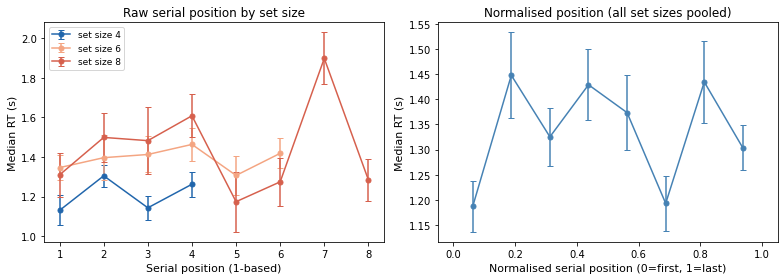

In [9]:
in_df  = df[df['trial_type'] == 'IN'].dropna(subset=['serial_pos']).copy()

# Plot by normalised position (comparable across set sizes)
in_df['pos_norm'] = in_df.apply(
    lambda r: (r['serial_pos'] - 1) / (r['size'] - 1), axis=1
)

# Bin into 8 equal bins for plotting
in_df['pos_bin'] = pd.cut(in_df['pos_norm'], bins=8, labels=False)
pos_rt = in_df.groupby('pos_bin')['rt'].agg(['median','sem']).reset_index()
bin_centres = [(i + 0.5) / 8 for i in range(8)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: raw position per set size
colors = {4: '#2166ac', 6: '#f4a582', 8: '#d6604d'}
for ss, grp in in_df.groupby('size'):
    pos_ss = grp.groupby('serial_pos')['rt'].agg(['median','sem']).reset_index()
    axes[0].errorbar(pos_ss['serial_pos'], pos_ss['median'],
                     yerr=pos_ss['sem'], fmt='o-', color=colors[ss],
                     capsize=3, linewidth=1.5, markersize=5, label=f'set size {ss}')
axes[0].set_xlabel('Serial position (1-based)', fontsize=11)
axes[0].set_ylabel('Median RT (s)', fontsize=11)
axes[0].set_title('Raw serial position by set size', fontsize=12)
axes[0].legend(fontsize=9)

# Right: normalised position (pooled across set sizes)
axes[1].errorbar(bin_centres, pos_rt['median'],
                 yerr=pos_rt['sem'], fmt='o-', color='steelblue',
                 capsize=3, linewidth=1.5, markersize=5)
axes[1].set_xlabel('Normalised serial position (0=first, 1=last)', fontsize=11)
axes[1].set_ylabel('Median RT (s)', fontsize=11)
axes[1].set_title('Normalised position (all set sizes pooled)', fontsize=12)
axes[1].set_xlim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('serial_position_RT.pdf', dpi=150)
plt.show()


### 8b. Phonological similarity vs. RT


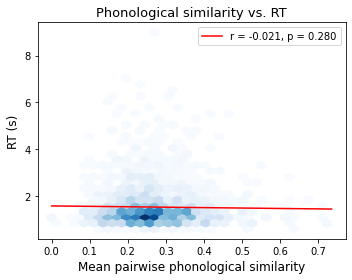

Raw correlation — phon_sim vs RT: r = -0.021, p = 0.2796


In [10]:
valid = df[['phon_sim', 'rt']].dropna()
r, p  = pearsonr(valid['phon_sim'], valid['rt'])

fig, ax = plt.subplots(figsize=(5, 4))
ax.hexbin(valid['phon_sim'], valid['rt'], gridsize=30, cmap='Blues', mincnt=1)
m, b = np.polyfit(valid['phon_sim'], valid['rt'], 1)
xs   = np.linspace(valid['phon_sim'].min(), valid['phon_sim'].max(), 100)
ax.plot(xs, m * xs + b, 'r-', linewidth=1.5,
        label=f'r = {r:.3f}, p = {p:.3f}')
ax.set_xlabel('Mean pairwise phonological similarity', fontsize=12)
ax.set_ylabel('RT (s)', fontsize=12)
ax.set_title('Phonological similarity vs. RT', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('phon_similarity_RT.pdf', dpi=150)
plt.show()
print(f'Raw correlation — phon_sim vs RT: r = {r:.3f}, p = {p:.4f}')


### 8c. Phonological similarity matrix heatmap


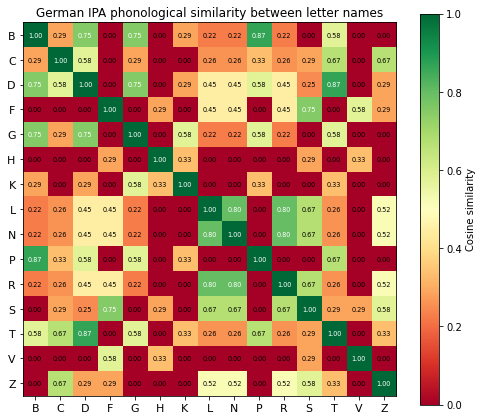

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(COS_SIM, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(15))
ax.set_yticks(range(15))
ax.set_xticklabels(LETTERS, fontsize=11)
ax.set_yticklabels(LETTERS, fontsize=11)
plt.colorbar(im, ax=ax, label='Cosine similarity')
ax.set_title('German IPA phonological similarity between letter names', fontsize=12)

for i in range(15):
    for j in range(15):
        ax.text(j, i, f'{COS_SIM[i,j]:.2f}',
                ha='center', va='center', fontsize=6.5,
                color='black' if COS_SIM[i,j] < 0.7 else 'white')

plt.tight_layout()
plt.savefig('phon_similarity_matrix.pdf', dpi=150)
plt.show()


## 9. Interpretation of Results

Results are reported as β [95% CI], t-value, p-value.

### Decoding accuracy (β = −2.659 [−4.888, −0.429], t = −2.337, p = 0.019)
The original finding is replicated and survives the addition of two
phonological confound predictors. Trials in which the letters of the
encoding string are more strongly represented in MTL population activity
are associated with faster response times. Crucially, this effect holds
after explicitly controlling for both the phonological homogeneity of
the string and the phonological similarity between the probe and the
string, directly addressing Reviewer 3 Comment 7. The neural
representation-strength account therefore cannot be reduced to a
phonological confound.

### Phonological similarity of the string (β = −0.455 [−0.777, −0.134], t = −2.778, p = 0.005)
This effect is significant but in the **opposite direction** to the
simple phonological-loop interference prediction: strings composed of
more phonologically similar letters are associated with *faster*, not
slower, response times. One interpretation is that letters sharing
articulatory and acoustic features (e.g. the German /eː/ rhyme group
B C D G P T) are easier to rehearse as a cohesive phonological unit,
reducing the overall maintenance cost in the phonological loop. An
alternative possibility is that similarity-driven chunking reduces the
effective set size experienced during scanning. The direction of this
effect is not consistent with a simple confusability account and merits
discussion as a novel observation.

### Probe–string phonological similarity (β = +0.528 [+0.237, +0.819], t = +3.558, p = 0.0004)
This is the strongest new effect and goes in the predicted direction.
When the probe letter sounds similar to the letters held in memory,
response times are slower, consistent with phonological interference
during the comparison stage at retrieval. A probe that is phonologically
distinct from the string (e.g. V = /faʊ/ probing a string of /eː/
letters) is identified more rapidly. This effect is significant
independently of decoding accuracy, indicating that phonological
discriminability at retrieval explains variance in RT that neural
representation strength alone does not. The two predictors therefore
capture complementary aspects of working memory performance.

### Serial position, normalised (β = +0.039 [−0.069, +0.146], t = +0.701, p = 0.484)
The normalised position of the probe within the encoding string does
not significantly predict response time once the other predictors are
controlled. This null result directly answers Reviewer 3 Comment 7:
serial position was explicitly included in the model and does not account
for the decoding accuracy effect. Importantly, the linear LME term
tests only for a monotonic trend; the post-hoc Kruskal–Wallis test
and permutation comparisons in Section 9a below additionally test
whether RT departs from uniformity across positions in a non-linear
fashion (e.g. a U-shaped primacy–recency curve).

### Covariates
IN trials are faster than OUT trials (β = −0.145 [−0.201, −0.090],
t = −5.139, p = 2.8×10⁻⁷), replicating the original finding and
consistent with self-terminating search on match trials. Response time
increases with set size (6 vs. 4: β = +0.217, p = 7.7×10⁻¹¹;
8 vs. 4: β = +0.341, p = 1.6×10⁻²¹), confirming the serial scanning
process. No individual probe letter reaches significance after FDR
correction, indicating that probe-level RT variance is captured by the
continuous phonological and decoding predictors rather than by letter
identity per se.

### Summary
The revised model provides three independent lines of evidence relevant
to Reviewer 3 Comment 7. First, the decoding accuracy effect is robust
to explicit phonological control (β = −2.659, p = 0.019), ruling out
phonological confusability as an alternative explanation. Second,
probe–string phonological similarity exerts an independent, expected
effect on RT (β = +0.528, p = 0.0004), validating the German IPA
feature matrix and confirming that the paradigm is sensitive to
phonological confusability at retrieval. Third, serial position does
not explain the decoding accuracy effect (β = +0.039, p = 0.484),
consistent with the simultaneous presentation design in which position
cues are not informative for the scanning process. The unexpected
negative sign on string similarity (β = −0.455, p = 0.005) is an
interesting observation that may reflect phonological chunking during
rehearsal and is discussed as a novel finding.


### 9a. Post-hoc test: is RT uniform across serial positions?

The LME serial position term (Section 6) tests a *linear* trend in RT
as a function of normalised position. A non-significant linear coefficient
(β = +0.039, p = 0.484) does not rule out non-linear patterns such as
a U-shaped primacy–recency curve.

We therefore apply two complementary non-parametric tests, run
separately per set size to avoid confounding position with string length:

1. **Kruskal–Wallis test** across all serial positions within each set
   size. Tests the omnibus null hypothesis that RT is identically
   distributed across all positions (including non-linear patterns).

2. **Permutation test (two-tailed)** comparing median RT at the first
   vs. last position within each set size. Tests for classic primacy
   vs. recency asymmetry. The null distribution is obtained by randomly
   reassigning the first/last labels across 5,000 permutations.


Kruskal–Wallis test: RT across serial positions (per set size)
────────────────────────────────────────────────────────────
  Set size 4: H(3) = 11.146, p = 0.0110  *
  (n = 519 trials across 4 positions)
  Set size 6: H(5) = 5.418, p = 0.3670  n.s.
  (n = 376 trials across 6 positions)
  Set size 8: H(7) = 23.216, p = 0.0016  **
  (n = 296 trials across 8 positions)

Permutation test: first vs. last position (primacy vs. recency, IN trials)
────────────────────────────────────────────────────────────
  Set size 4: median RT first pos = 1.131 s, last pos = 1.263 s
  Δmedian = -0.132 s, permutation p = 0.0006  **
  Set size 6: median RT first pos = 1.347 s, last pos = 1.419 s
  Δmedian = -0.072 s, permutation p = 0.3296  n.s.
  Set size 8: median RT first pos = 1.310 s, last pos = 1.285 s
  Δmedian = +0.025 s, permutation p = 0.6626  n.s.


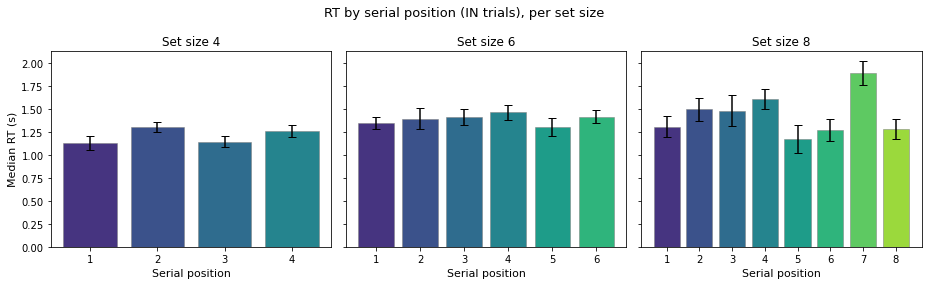

In [12]:
from scipy.stats import kruskal

in_df = df[df['trial_type'] == 'IN'].dropna(subset=['serial_pos']).copy()
in_df['size_int'] = in_df['size'].astype(int)

# ── Kruskal–Wallis per set size ──────────────────────────────────────────
print('Kruskal–Wallis test: RT across serial positions (per set size)')
print('─' * 60)
for ss in [4, 6, 8]:
    sub = in_df[in_df['size_int'] == ss]
    groups = [grp['rt'].values for _, grp in sub.groupby('serial_pos')]
    groups = [g for g in groups if len(g) >= 5]  # require at least 5 obs per group
    if len(groups) < 2:
        print(f'  Set size {ss}: insufficient data')
        continue
    stat, p = kruskal(*groups)
    n_pos   = len(groups)
    n_total = sum(len(g) for g in groups)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    print(f'  Set size {ss}: H({n_pos-1}) = {stat:.3f}, p = {p:.4f}  {sig}')
    print(f'  (n = {n_total} trials across {n_pos} positions)')

# ── Permutation pairwise test: first vs last position (per set size) ─────
print()
print('Permutation test: first vs. last position (primacy vs. recency, IN trials)')
print('─' * 60)
N_PERM = 5000
rng    = np.random.default_rng(42)

for ss in [4, 6, 8]:
    sub    = in_df[in_df['size_int'] == ss]
    first  = sub[sub['serial_pos'] == 1]['rt'].values
    last   = sub[sub['serial_pos'] == ss]['rt'].values
    if len(first) < 5 or len(last) < 5:
        continue
    obs_diff = np.median(first) - np.median(last)
    combined = np.concatenate([first, last])
    n_first  = len(first)
    null     = np.array([
        np.median(rng.choice(combined, n_first, replace=False)) -
        np.median(rng.choice(combined, len(last), replace=False))
        for _ in range(N_PERM)
    ])
    p_perm = np.mean(np.abs(null) >= np.abs(obs_diff))
    sig    = '**' if p_perm < 0.01 else ('*' if p_perm < 0.05 else 'n.s.')
    print(f'  Set size {ss}: median RT first pos = {np.median(first):.3f} s, '
          f'last pos = {np.median(last):.3f} s')
    print(f'  Δmedian = {obs_diff:+.3f} s, permutation p = {p_perm:.4f}  {sig}')

# ── Plot: RT by raw position, per set size ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
colors_pos = plt.cm.viridis(np.linspace(0.15, 0.85, 8))

for ax, ss in zip(axes, [4, 6, 8]):
    sub    = in_df[in_df['size_int'] == ss]
    pos_rt = sub.groupby('serial_pos')['rt'].agg(
        median='median', sem='sem'
    ).reset_index()
    ax.bar(pos_rt['serial_pos'], pos_rt['median'],
           yerr=pos_rt['sem'], color=colors_pos[:len(pos_rt)],
           capsize=4, edgecolor='grey', linewidth=0.5)
    ax.set_title(f'Set size {ss}', fontsize=12)
    ax.set_xlabel('Serial position', fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel('Median RT (s)', fontsize=11)
    ax.set_xticks(range(1, ss + 1))

fig.suptitle('RT by serial position (IN trials), per set size', fontsize=13)
plt.tight_layout()
plt.savefig('serial_position_RT_posthoc.pdf', dpi=150)
plt.show()


## Notes for manuscript

### Phonological feature matrix (German)
Each letter is described by 17 binary features derived from the IPA
transcription of its German name (Hochdeutsch):
- **Manner** (6): stop, fricative, affricate, nasal, lateral, trill
- **Place** (5): bilabial, labiodental, alveolar, velar, glottal
- **Voicing** (1)
- **Onset type** (1): vowel_onset (F, L, N, R, S — names starting with /ɛ/)
- **Rhyme group** (4): /eː/ (B C D G P T), /aː/ (H K), /ɛ_/ (F L N R S Z), /aʊ/ (V)

### Phonological predictors
Two trial-level phonological predictors are entered in the model:

**`phon_sim` (string similarity):** Mean pairwise cosine similarity among all
letter names in the encoding string. Higher values indicate a more
phonologically homogeneous string, expected to cause greater interference
in the phonological loop (Baddeley, 2003). Predicted sign: β > 0.

**`probe_phon_sim` (probe–string similarity):** Mean cosine similarity between
the probe letter name and the letter names in the encoding string
(probe excluded on IN trials). Lower values indicate a more
phonologically distinct probe, expected to facilitate identification.
Predicted sign: β > 0 (higher similarity → slower RT).

Both are mean-centred over all trials before entry into the model.

### Serial position (normalised)
The encoding strings preserve left-to-right visual display order.
Serial position is extracted for IN trials only and normalised by set size:
`serial_pos_norm = (pos − 1) / (set_size − 1)`, mapping leftmost → 0, rightmost → 1.
This allows pooling across set sizes 4, 6, and 8 without a length confound.
The predictor is then mean-centred within IN trials to avoid collinearity
with the IN/OUT trial-type dummy; OUT trials take the value 0.

### Centring summary
| Predictor | Centring | Rationale |
|---|---|---|
| `predicted_c` | Grand mean | Interpretable intercept |
| `phon_sim_c` | Grand mean | Reduces collinearity with `predicted_c` |
| `probe_phon_sim_c` | Grand mean | Same scale as `phon_sim_c` |
| `serial_pos_norm_IN_c` | Mean of IN trials | Eliminates collinearity with trial-type dummy |

### Observed results summary
Based on the fitted model:
- **Decoding accuracy** (β = −2.659, p = 0.019): confirmed, robust to phonological control
- **String phonological similarity** (β = −0.455, p = 0.005): significant but reversed direction — faster RT for similar strings (possible chunking effect)
- **Probe–string similarity** (β = +0.528, p = 0.0004): significant in predicted direction — similar probe → slower RT
- **Serial position** (β = +0.039, p = 0.484): not significant; post-hoc non-parametric tests in Section 9a
  the decoding accuracy effect survives control for phonological confusability and position
